# Differentiating Through Solve

Because gaussx primitives are pure JAX functions built on lineax
and equinox, they are fully differentiable. This notebook shows
how to use `jax.grad` and `jax.jacobian` through `gaussx.solve`
for inverse problems and sensitivity analysis.

In [1]:
from __future__ import annotations

from pathlib import Path

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


try:
    _here = Path(__file__).resolve().parent
except NameError:
    _here = Path.cwd()
IMG_DIR = _here.parent / "images" / "differentiating_solve"
IMG_DIR.mkdir(parents=True, exist_ok=True)

jax.config.update("jax_enable_x64", True)

## 1. Gradient of a loss through solve

Consider optimizing a parameter $\theta$ that appears in the
matrix $A(\theta)$. We want $\nabla_\theta \|A(\theta)^{-1} b - x^*\|^2$.

In [2]:
def build_op(theta):
    """Build a PSD matrix parameterized by theta."""
    # Diagonal + scaled off-diagonal coupling
    diag = jnp.array([1.0, 2.0, 3.0]) + theta
    off = theta * 0.1
    mat = jnp.diag(diag) + off * (jnp.ones((3, 3)) - jnp.eye(3))
    return lx.MatrixLinearOperator(mat, lx.positive_semidefinite_tag)


b = jnp.array([1.0, 2.0, 3.0])
x_target = jnp.array([0.5, 0.5, 0.5])


def loss(theta):
    op = build_op(theta)
    x = gaussx.solve(op, b)
    return jnp.sum((x - x_target) ** 2)


theta = 1.0
print(f"loss(theta={theta}): {loss(theta):.6f}")

grad_loss = jax.grad(loss)
print(f"grad(theta={theta}): {grad_loss(theta):.6f}")

# Verify with finite differences
eps = 1e-5
fd_grad = (loss(theta + eps) - loss(theta - eps)) / (2 * eps)
print(f"finite diff grad:    {fd_grad:.6f}")
print(f"match: {jnp.allclose(grad_loss(theta), fd_grad, rtol=1e-4)}")

loss(theta=1.0): 0.070932


grad(theta=1.0): -0.111321
finite diff grad:    -0.111321
match: True


## 2. Gradient sweep over theta

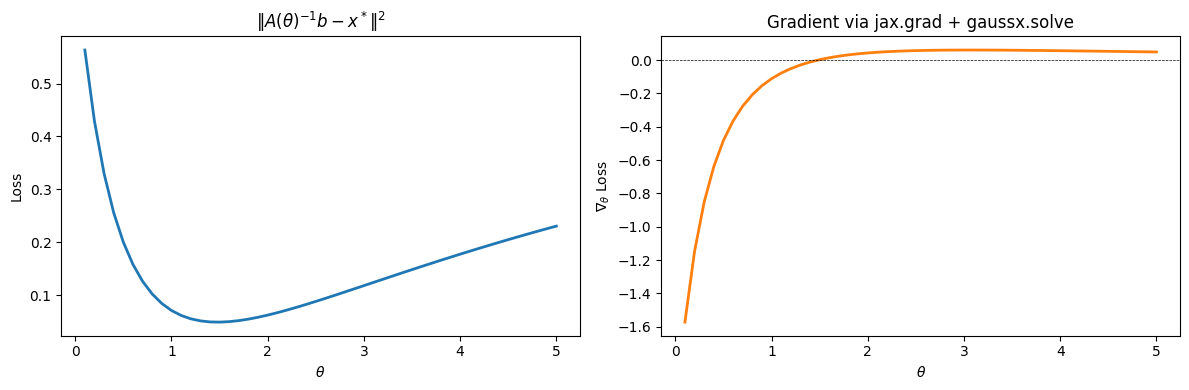

In [3]:
thetas = jnp.linspace(0.1, 5.0, 50)
losses = jax.vmap(loss)(thetas)
grads = jax.vmap(grad_loss)(thetas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thetas, losses, "C0-", lw=2)
axes[0].set_xlabel("$\\theta$")
axes[0].set_ylabel("Loss")
axes[0].set_title("$\\|A(\\theta)^{-1}b - x^*\\|^2$")

axes[1].plot(thetas, grads, "C1-", lw=2)
axes[1].axhline(0, color="k", lw=0.5, ls="--")
axes[1].set_xlabel("$\\theta$")
axes[1].set_ylabel("$\\nabla_\\theta$ Loss")
axes[1].set_title("Gradient via jax.grad + gaussx.solve")

plt.tight_layout()
fig.savefig(IMG_DIR / "gradient_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

![Gradient sweep](../images/differentiating_solve/gradient_sweep.png)

## 3. Gradient descent to find optimal theta

In [4]:
theta = 3.0  # starting point
lr = 0.5
trajectory = [theta]

for _i in range(30):
    g = grad_loss(theta)
    theta = theta - lr * g
    trajectory.append(float(theta))

trajectory = jnp.array(trajectory)
print(f"Optimal theta: {trajectory[-1]:.4f}")
print(f"Final loss: {loss(trajectory[-1]):.8f}")

Optimal theta: 2.1412
Final loss: 0.06871058


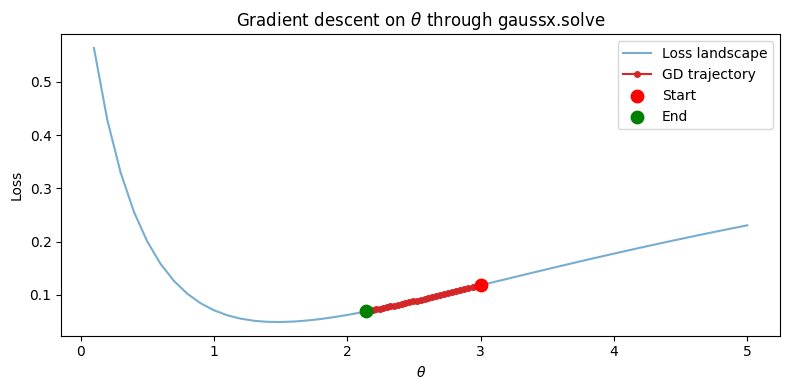

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thetas, losses, "C0-", lw=1.5, alpha=0.6, label="Loss landscape")
ax.plot(trajectory, jax.vmap(loss)(trajectory), "C3o-", ms=4, label="GD trajectory")
ax.scatter(trajectory[0], loss(trajectory[0]), s=80, c="red", zorder=5, label="Start")
ax.scatter(trajectory[-1], loss(trajectory[-1]), s=80, c="green", zorder=5, label="End")
ax.set_xlabel("$\\theta$")
ax.set_ylabel("Loss")
ax.set_title("Gradient descent on $\\theta$ through gaussx.solve")
ax.legend()
plt.tight_layout()
fig.savefig(IMG_DIR / "optimization.png", dpi=150, bbox_inches="tight")
plt.show()

![Optimization trajectory](../images/differentiating_solve/optimization.png)

## 4. Differentiating logdet

$\nabla_\theta \log|A(\theta)|$
$= \mathrm{tr}(A(\theta)^{-1} \partial A / \partial \theta)$

gaussx + JAX computes this automatically.

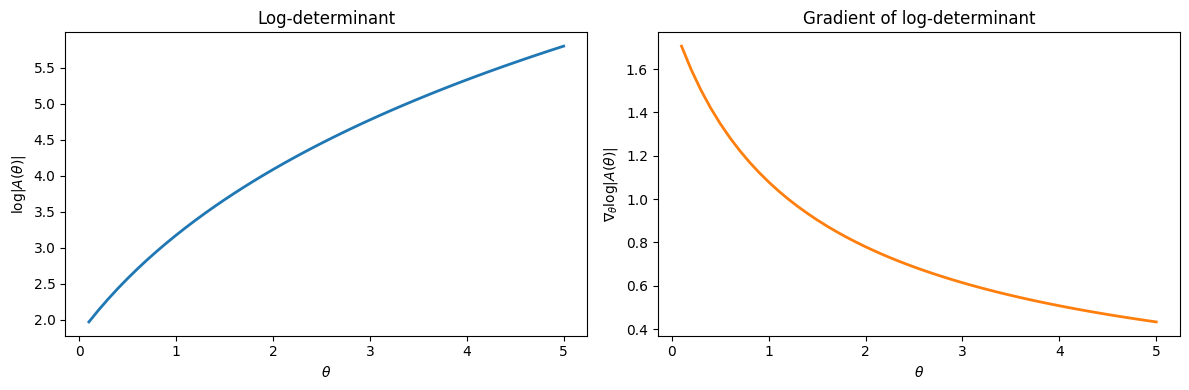

In [6]:
def logdet_of_theta(theta):
    op = build_op(theta)
    return gaussx.logdet(op)


grad_logdet = jax.grad(logdet_of_theta)

logdets = jax.vmap(logdet_of_theta)(thetas)
grad_logdets = jax.vmap(grad_logdet)(thetas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thetas, logdets, "C0-", lw=2)
axes[0].set_xlabel("$\\theta$")
axes[0].set_ylabel("$\\log|A(\\theta)|$")
axes[0].set_title("Log-determinant")

axes[1].plot(thetas, grad_logdets, "C1-", lw=2)
axes[1].set_xlabel("$\\theta$")
axes[1].set_ylabel("$\\nabla_\\theta \\log|A(\\theta)|$")
axes[1].set_title("Gradient of log-determinant")

plt.tight_layout()
fig.savefig(IMG_DIR / "logdet_gradient.png", dpi=150, bbox_inches="tight")
plt.show()

![Logdet gradient](../images/differentiating_solve/logdet_gradient.png)

## Summary

| What | How |
|------|-----|
| grad of solve | `jax.grad(lambda t: f(gaussx.solve(A(t), b)))` |
| $\nabla_\theta \log|A(\theta)|$ | `jax.grad(lambda t: gaussx.logdet(A(t)))` |
| Jacobian | `jax.jacobian(lambda t: gaussx.solve(A(t), b))` |
| Batched gradients | `jax.vmap(jax.grad(loss))` |

All gaussx primitives support arbitrary-order differentiation
because they are built on lineax (which provides custom JVP rules
for `linear_solve`) and standard JAX operations.